### CSV Course Specifications

This is a demonstration of the course specifications linear regression algorithm using a CSV for input. This allows students to use larger data sets.

This can also be viewed as a Python script in [5.export_import.py](5.export_import.py.) and [5.test_import.py](5.test_import.py).

#### Step 1

Load the required dependencies including [pickle](https://docs.python.org/3/library/pickle.html) the native Python library for serialising data objects:

> [!Caution]
> The pickle module is not secure. Only unpickle data you trust.

In [47]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2
- Open and parse the CSV file and store the data as variable array objects.

In [48]:
training_data = pd.read_csv("course_specifications_data.csv", delimiter=",")
x = np.array(training_data["events_completed"], dtype=float)
y = np.array(training_data["average"], dtype=float)

#### Optional Step

Apply your Python skills and query the data set about how many training examples there are and inspect a sample of the data.

In [49]:
m = len(x)
print(f"Number of training examples is: {m}")
table = pd.DataFrame({
    training_data.columns[0]: x.flatten(),  # Flatten x for easy display
    training_data.columns[1]: y
})
print(table.head())

Number of training examples is: 9715
   events_completed   average
0               2.0  0.718471
1               1.0  0.456221
2               1.0  0.353376
3               2.0  0.314862
4               1.0  0.462972


#### Step 3

Use the [sklearn](https://scikit-learn.org/stable/) library to fit the model to the training data which will provide a line of best fit with the lowest cost based on a [sklearn](https://scikit-learn.org/stable/) algorithm.

In [50]:
filename = "my_saved_poly_v3.pkl"
model_data = pickle.load(open(filename, "rb"))
a, b, c = model_data["a"], model_data["b"], model_data["c"]


# Reconstruct the exponential function
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c


print(f"Model loaded: a={a:.4f}, b={b:.4f}, c={c:.4f}")

Model loaded: a=0.3163, b=0.0203, c=0.1128


#### Step 4

Save the model to file.

In [51]:
# Model is already saved as my_saved_poly_v3.pkl - no need to re-save
print(f"Model is saved as: {filename}")
print(f"Parameters: a={a:.4f}, b={b:.4f}, c={c:.4f}")

Model is saved as: my_saved_poly_v3.pkl
Parameters: a=0.3163, b=0.0203, c=0.1128


#### Step 5
In a separate Python implementation import the file and make a prediction.

In [52]:
# Load model and make a prediction
predict = 4
result = exp_func(predict, a, b, c)
print(f"Predicted average for {predict} events completed: {result:.4f}")

Predicted average for 4 events completed: 0.4045


#### Optional Step

Plot the features, targets and model (linear regression).

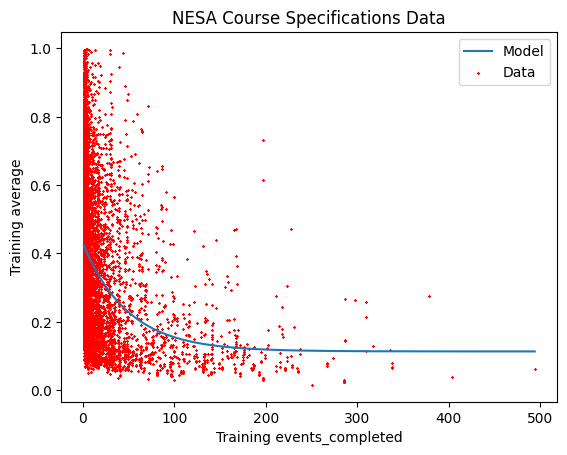

In [53]:
x_sorted = np.sort(x)
y_pred = exp_func(x_sorted, a, b, c)
plt.plot(x_sorted, y_pred, label="Model")
plt.scatter(x, y, marker='x', c='r', s=1, label="Data")
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Training {training_data.columns[1]}')
plt.xlabel(f'Training {training_data.columns[0]}')
plt.legend()
plt.show()

#### Optional Step

Use the model for predictions and plot them on the visualisation that is saved as file `graph.png` for use in a Python Flask UI API endpoint.

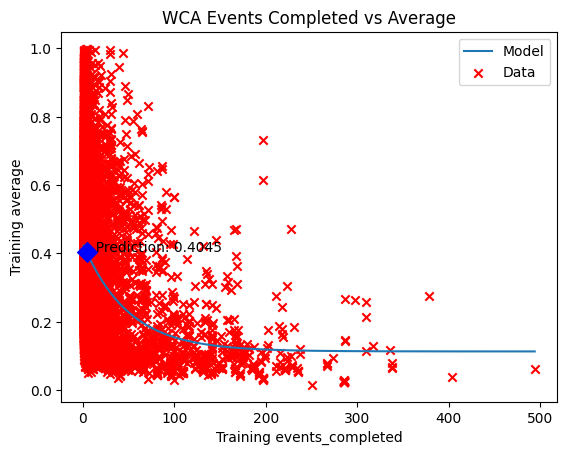

In [55]:
x_line = np.linspace(min(x), max(x), 200)
y_line = exp_func(x_line, a, b, c)

predict_val = 4
y_prediction = exp_func(predict_val, a, b, c)

plt.plot(x_line, y_line, label="Model")
plt.scatter(x, y, marker="x", c="r", label="Data")
plt.scatter(predict_val, y_prediction, marker="D", c="blue", zorder=10, s=100)
plt.text(predict_val, y_prediction, f"  Prediction: {y_prediction:.4f}")
plt.title("WCA Events Completed vs Average")
plt.ylabel(f"Training {training_data.columns[1]}")
plt.xlabel(f"Training {training_data.columns[0]}")
plt.legend()
plt.savefig("graph.png")
plt.show()

### Range

Removed 486 outliers above 0.7544
Using window ±10, found 98 nearby points


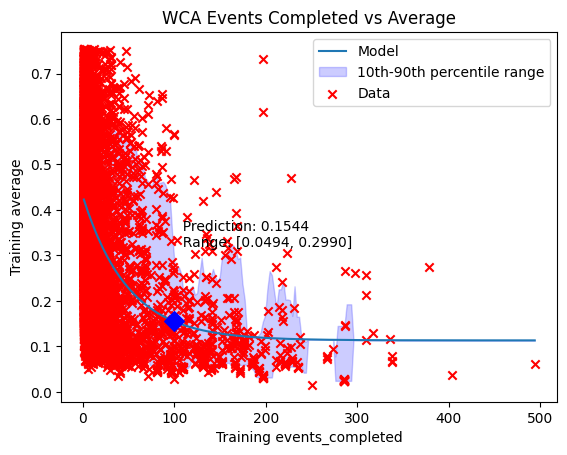

Predicted average for 100 events: 3.84s
Potential solving range: [1.36s, 7.24s]


In [86]:
x_line = np.linspace(min(x), max(x), 200)
y_line = exp_func(x_line, a, b, c)

predict_val = 100

MIN_AVG = 200
MAX_AVG = 23750

def unscale(scaled_val):
    return scaled_val * (MAX_AVG - MIN_AVG) + MIN_AVG

# Remove outliers from the dataset before calculating range
upper_threshold = np.percentile(y, 95)
mask_clean = y <= upper_threshold
x_clean = x[mask_clean]
y_clean = y[mask_clean]

print(f"Removed {len(x) - len(x_clean)} outliers above {upper_threshold:.4f}")

y_prediction = exp_func(predict_val, a, b, c)

# Adaptive window using cleaned data
window = 10
nearby_mask = (x_clean >= predict_val - window) & (x_clean <= predict_val + window)
nearby_y = y_clean[nearby_mask]

while len(nearby_y) < 30 and window < 100:
    window += 10
    nearby_mask = (x_clean >= predict_val - window) & (x_clean <= predict_val + window)
    nearby_y = y_clean[nearby_mask]

if len(nearby_y) > 0:
    y_lower = np.percentile(nearby_y, 10)
    y_upper = np.percentile(nearby_y, 90)
else:
    y_lower = y_prediction - 0.05
    y_upper = y_prediction + 0.05

print(f"Using window ±{window}, found {len(nearby_y)} nearby points")

# Build band using cleaned data
y_lower_band = np.array([
    np.percentile(y_clean[(x_clean >= xv - window) & (x_clean <= xv + window)], 10)
    if np.sum((x_clean >= xv - window) & (x_clean <= xv + window)) >= 5
    else exp_func(xv, a, b, c)
    for xv in x_line
])
y_upper_band = np.array([
    np.percentile(y_clean[(x_clean >= xv - window) & (x_clean <= xv + window)], 90)
    if np.sum((x_clean >= xv - window) & (x_clean <= xv + window)) >= 5
    else exp_func(xv, a, b, c)
    for xv in x_line
])

plt.plot(x_line, y_line, label="Model")
plt.fill_between(x_line, y_lower_band, y_upper_band, alpha=0.2, color="blue", label="10th-90th percentile range")
plt.scatter(x_clean, y_clean, marker="x", c="r", label="Data")  # plot clean data
plt.scatter(predict_val, y_prediction, marker="D", c="blue", zorder=10, s=100)
plt.text(
    predict_val, y_upper + 0.02,
    f"  Prediction: {y_prediction:.4f}\n  Range: [{y_lower:.4f}, {y_upper:.4f}]",
)
plt.title("WCA Events Completed vs Average")
plt.ylabel(f"Training {training_data.columns[1]}")
plt.xlabel(f"Training {training_data.columns[0]}")
plt.legend()
plt.savefig("graph.png")
plt.show()

y_prediction_time = unscale(y_prediction)
y_lower_time = unscale(y_lower)
y_upper_time = unscale(y_upper)

print(f"Predicted average for {predict_val} events: {y_prediction_time/1000:.2f}s")
print(f"Potential solving range: [{y_lower_time/1000:.2f}s, {y_upper_time/1000:.2f}s]")